# DenseNet121 for Retinal OCT Classification
Training on RetinalOCT_Dataset without augmentation

In [1]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

print('TensorFlow:', tf.__version__)
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

TensorFlow: 2.17.0


In [2]:
# GPU Configuration and Verification
print('=' * 60)
print('GPU CONFIGURATION')
print('=' * 60)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
print(f'\nNumber of GPUs Available: {len(gpus)}')

if gpus:
    try:
        # Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Display GPU details
        for i, gpu in enumerate(gpus):
            print(f'\nGPU {i}: {gpu}')
            gpu_details = tf.config.experimental.get_device_details(gpu)
            if gpu_details:
                print(f'  Device Name: {gpu_details.get("device_name", "N/A")}')
        
        # Set GPU as visible device
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f'\nLogical GPUs: {len(logical_gpus)}')
        print('✓ GPU is configured and will be used for training')
        
    except RuntimeError as e:
        print(f'GPU configuration error: {e}')
else:
    print('⚠ No GPU detected. Training will use CPU (this will be slower)')
    print('Make sure you have:')
    print('  1. NVIDIA GPU with CUDA support')
    print('  2. CUDA Toolkit installed')
    print('  3. cuDNN installed')
    print('  4. tensorflow-gpu or tensorflow>=2.0 installed')

print('\n' + '=' * 60)

GPU CONFIGURATION

Number of GPUs Available: 0
⚠ No GPU detected. Training will use CPU (this will be slower)
Make sure you have:
  1. NVIDIA GPU with CUDA support
  2. CUDA Toolkit installed
  3. cuDNN installed
  4. tensorflow-gpu or tensorflow>=2.0 installed



In [3]:
# Configuration
BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'RetinalOCT_Dataset')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
VAL_DIR = os.path.join(DATA_DIR, 'val')
IMG_SIZE = (224, 224)

# Optimize batch size for GPU (increase if you have more VRAM)
# 32 is safe for most GPUs, increase to 64 or 128 if you have 8GB+ VRAM
BATCH_SIZE = 64 if len(tf.config.list_physical_devices('GPU')) > 0 else 32
NUM_WORKERS = tf.data.AUTOTUNE

print('Train dir exists:', os.path.exists(TRAIN_DIR))
print('Test dir exists:', os.path.exists(TEST_DIR))
print('Val dir exists:', os.path.exists(VAL_DIR))
print(f'Batch size: {BATCH_SIZE}')

Train dir exists: True
Test dir exists: True
Val dir exists: True
Batch size: 32


In [4]:
# Data loading functions
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def scan_folder(folder):
    """Scan folder and return paths, labels, and class names"""
    class_names = sorted([d.name for d in pathlib.Path(folder).iterdir() if d.is_dir()])
    paths, labels = [], []
    for idx, cname in enumerate(class_names):
        cdir = pathlib.Path(folder) / cname
        for p in cdir.rglob('*'):
            if not p.is_file() or p.suffix.lower() not in IMG_EXTS:
                continue
            # Validate with PIL to drop corrupt files
            try:
                with Image.open(p) as im:
                    im.verify()
            except Exception:
                continue
            paths.append(str(p))
            labels.append(idx)
    return np.array(paths), np.array(labels, dtype=np.int64), class_names

def decode_and_resize(path):
    """Decode and resize image"""
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    return image

def paths_labels_to_ds(paths, labels, shuffle=False):
    """Convert paths and labels to tf.data.Dataset"""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    
    def _map(path, label):
        img = decode_and_resize(path)
        return img, label
    
    ds = ds.map(_map, num_parallel_calls=NUM_WORKERS)
    ds = ds.batch(BATCH_SIZE).prefetch(NUM_WORKERS)
    
    try:
        ds = ds.ignore_errors()
    except AttributeError:
        ds = ds.apply(tf.data.experimental.ignore_errors())
    
    return ds

In [5]:
# Load data
print('Loading training data...')
train_paths, train_labels, class_names = scan_folder(TRAIN_DIR)
print(f'Train samples: {len(train_paths)}')

print('Loading validation data...')
val_paths, val_labels, _ = scan_folder(VAL_DIR)
print(f'Validation samples: {len(val_paths)}')

print('Loading test data...')
test_paths, test_labels, _ = scan_folder(TEST_DIR)
print(f'Test samples: {len(test_paths)}')

num_classes = len(class_names)
print(f'\nNumber of classes: {num_classes}')
print(f'Class names: {class_names}')

Loading training data...
Train samples: 9200
Loading validation data...
Validation samples: 1400
Loading test data...
Test samples: 1400

Number of classes: 4
Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [6]:
# Create datasets
train_ds = paths_labels_to_ds(train_paths, train_labels, shuffle=True)
val_ds = paths_labels_to_ds(val_paths, val_labels, shuffle=False)
test_ds = paths_labels_to_ds(test_paths, test_labels, shuffle=False)

print('Datasets created successfully')

Datasets created successfully


In [7]:
# Compute class weights
def count_files_by_class(folder, classes):
    exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    counts = []
    for cname in classes:
        cdir = os.path.join(folder, cname)
        n = 0
        for root, _, files in os.walk(cdir):
            n += sum(1 for f in files if f.lower().endswith(exts))
        counts.append(n)
    return np.array(counts, dtype=np.int64)

train_counts = count_files_by_class(TRAIN_DIR, class_names)
weights = train_counts.sum() / (num_classes * train_counts.astype(np.float64))
class_weight = {i: float(w) for i, w in enumerate(weights)}

print('Training samples per class:', train_counts)
print('Class weights:', class_weight)

Training samples per class: [2300 2300 2300 2300]
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


In [8]:
# Custom plotting callback
class PlotTraining(keras.callbacks.Callback):
    def __init__(self, title_prefix='Phase', out_path='training_plot.png'):
        super().__init__()
        self.history = {k: [] for k in ['loss','val_loss','accuracy','val_accuracy']}
        self.title_prefix = title_prefix
        self.out_path = out_path
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for k in self.history.keys():
            if k in logs:
                self.history[k].append(logs[k])
        
        # Plot and save after each epoch
        plt.figure(figsize=(10, 6))
        plt.plot(self.history['accuracy'], label='Train Accuracy', marker='o')
        plt.plot(self.history['val_accuracy'], label='Val Accuracy', marker='o')
        plt.plot(self.history['loss'], label='Train Loss', marker='s')
        plt.plot(self.history['val_loss'], label='Val Loss', marker='s')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.title(f'{self.title_prefix} Training Progress')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(self.out_path, dpi=100)
        plt.close()

In [9]:
# Build DenseNet121 model
def build_model(num_classes, img_size=IMG_SIZE, base_trainable=False):
    base = DenseNet121(include_top=False, input_shape=(*img_size, 3), weights='imagenet', name='densenet121')
    base.trainable = base_trainable
    
    inputs = layers.Input(shape=(*img_size, 3))
    x = tf.keras.applications.densenet.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

print('Model architecture defined')

Model architecture defined


In [10]:
# Phase 1 – Feature Extraction (frozen base)
print('\n=== Phase 1: Feature Extraction ===')
model_p1 = build_model(num_classes, IMG_SIZE, base_trainable=False)
model_p1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

model_p1.summary()


=== Phase 1: Feature Extraction ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
# Train Phase 1
ckpt_p1 = os.path.join(BASE_DIR, 'densenet121_retinalOCT_phase1_best.keras')
plot_cb_p1 = PlotTraining(title_prefix='Phase 1', out_path='phase1_training.png')

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(ckpt_p1, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    plot_cb_p1
]

history_p1 = model_p1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_p1,
    class_weight=class_weight
)

Epoch 1/25
    288/Unknown 288s 951ms/step - accuracy: 0.3230 - loss: 1.8147

C:\Users\KARTHIK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.88753, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase1_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.3775 - loss: 1.5818 - val_accuracy: 0.6600 - val_loss: 0.8875 - learning_rate: 3.0000e-04
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.5247 - loss: 1.1486
Epoch 2: val_loss improved from 0.88753 to 0.74022, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase1_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.5475 - loss: 1.0903 - val_accuracy: 0.7264 - val_loss: 0.7402 - learning_rate: 3.0000e-04
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.5963 - loss: 0.9533
Epoch 3: val_loss improved from 0.74022 to 0.68541, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase1_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.6133 - loss: 0.9260 - val_accuracy: 0.7400 - val_loss: 0.6854 - learning_rate: 3.0000e-0

In [12]:
# Phase 2 – Fine-tuning (unfreeze base)
print('\n=== Phase 2: Fine-tuning ===')
model_p2 = build_model(num_classes, IMG_SIZE, base_trainable=True)
model_p2.load_weights(ckpt_p1)

model_p2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

print(f'Base model trainable: {model_p2.layers[2].trainable}')


=== Phase 2: Fine-tuning ===
Base model trainable: True


In [13]:
# Train Phase 2
ckpt_p2 = os.path.join(BASE_DIR, 'densenet121_retinalOCT_phase2_best.keras')
plot_cb_p2 = PlotTraining(title_prefix='Phase 2', out_path='phase2_training.png')

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(ckpt_p2, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    plot_cb_p2
]

history_p2 = model_p2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_p2,
    class_weight=class_weight
)

Epoch 1/25
    288/Unknown 1358s 5s/step - accuracy: 0.5039 - loss: 2.0486
Epoch 1: val_loss improved from None to 0.46494, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase2_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 1397s 5s/step - accuracy: 0.6379 - loss: 1.3126 - val_accuracy: 0.8493 - val_loss: 0.4649 - learning_rate: 1.0000e-05
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8222 - loss: 0.5168
Epoch 2: val_loss improved from 0.46494 to 0.31904, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase2_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 1360s 5s/step - accuracy: 0.8330 - loss: 0.4892 - val_accuracy: 0.8857 - val_loss: 0.3190 - learning_rate: 1.0000e-05
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8737 - loss: 0.3692
Epoch 3: val_loss improved from 0.31904 to 0.27876, saving model to d:\college\v-sem\DIP\densenet121_retinalOCT_phase2_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 1358s 5s/step - accuracy: 0.8791 - loss: 0.35

In [14]:
# Load best model and evaluate on test set
print('\n=== Evaluation on Test Set ===')
best_model = keras.models.load_model(ckpt_p2)

# Get predictions
y_true = []
y_pred = []
y_pred_proba = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_proba.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

print('Predictions collected')


=== Evaluation on Test Set ===
Predictions collected


In [15]:
# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_loss = log_loss(y_true, y_pred_proba)

print(f'\nTest Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Test Accuracy: 0.9229
Test Loss: 0.2429

=== Classification Report ===
              precision    recall  f1-score   support

         CNV     0.9134    0.9343    0.9237       350
         DME     0.9574    0.9000    0.9278       350
      DRUSEN     0.9101    0.8971    0.9036       350
      NORMAL     0.9130    0.9600    0.9359       350

    accuracy                         0.9229      1400
   macro avg     0.9235    0.9229    0.9228      1400
weighted avg     0.9235    0.9229    0.9228      1400



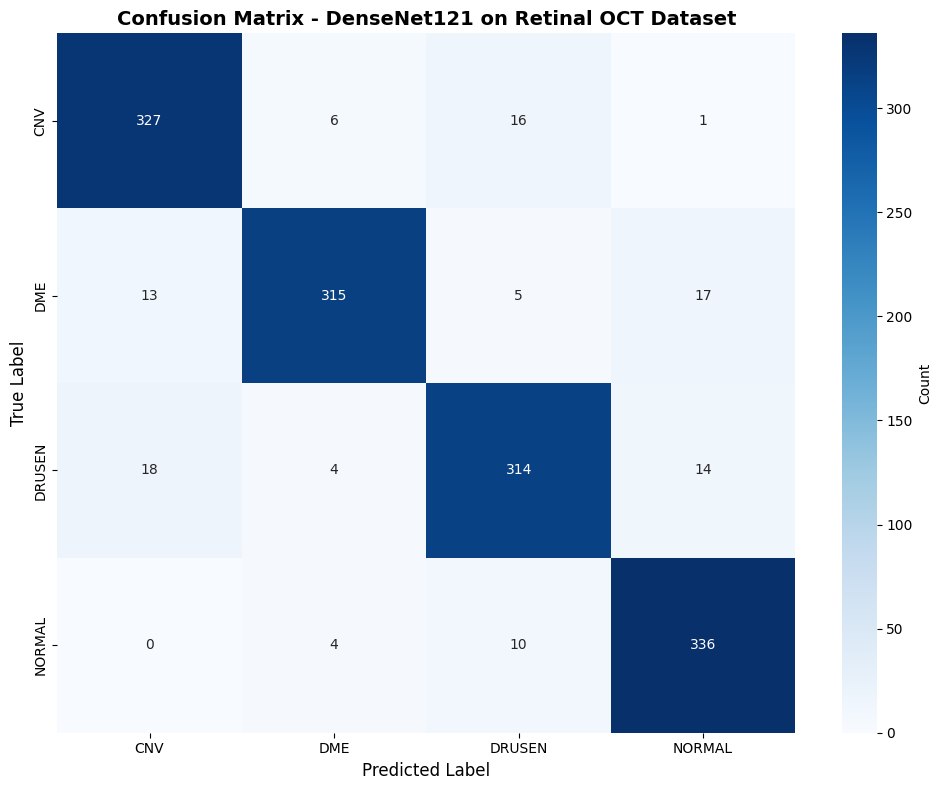


Confusion Matrix:
[[327   6  16   1]
 [ 13 315   5  17]
 [ 18   4 314  14]
 [  0   4  10 336]]


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - DenseNet121 on Retinal OCT Dataset', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConfusion Matrix:')
print(cm)

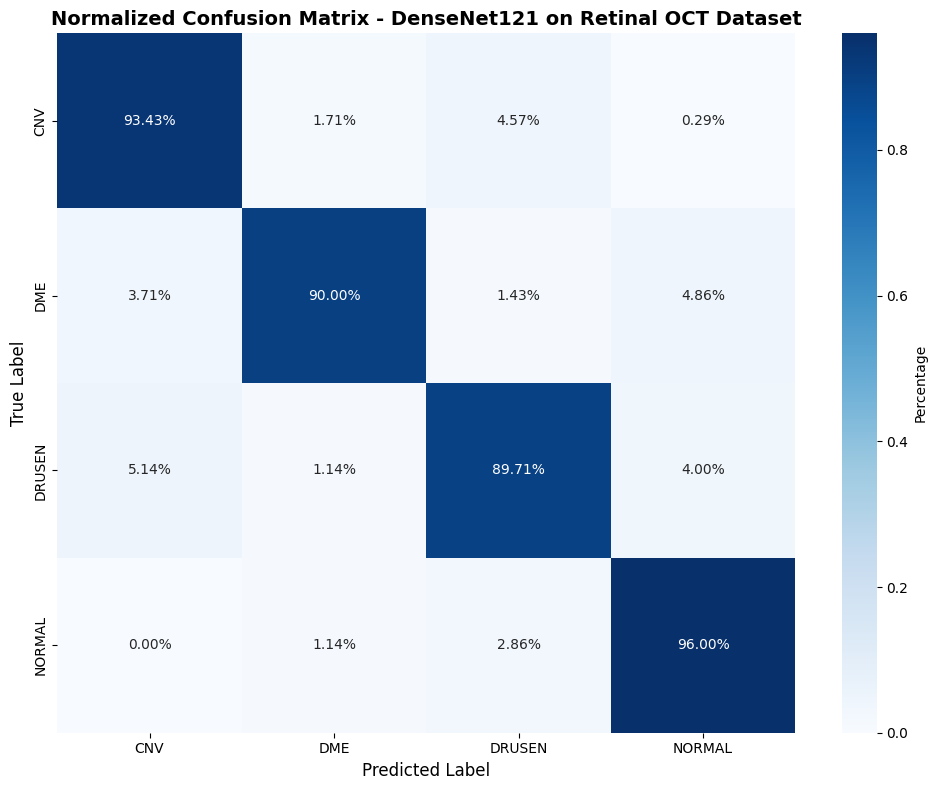


Normalized Confusion Matrix (%):
[[93.42857143  1.71428571  4.57142857  0.28571429]
 [ 3.71428571 90.          1.42857143  4.85714286]
 [ 5.14285714  1.14285714 89.71428571  4.        ]
 [ 0.          1.14285714  2.85714286 96.        ]]


In [17]:
# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - DenseNet121 on Retinal OCT Dataset', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNormalized Confusion Matrix (%):')
print(cm_normalized * 100)

In [18]:
# Save final results
results = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'confusion_matrix': cm.tolist(),
    'class_names': class_names,
    'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
}

import json
with open('test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('\nResults saved to test_results.json')
print('\n=== Training Complete ===')


Results saved to test_results.json

=== Training Complete ===
